<a href="https://colab.research.google.com/github/Jenipatel14/Edunet-Internship/blob/main/10_7_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("sustainability.csv")

# Preview
print(df.head())


   Entity Code  Year  Renewables (% equivalent primary energy)
0  Africa  NaN  1965                                  5.747495
1  Africa  NaN  1966                                  6.122062
2  Africa  NaN  1967                                  6.325731
3  Africa  NaN  1968                                  7.005293
4  Africa  NaN  1969                                  7.956088


In [ ]:
import pandas as pd

df = pd.read_csv("sustainability.csv")

# Handle nulls
df.fillna({'Code': 'Region'}, inplace=True)
df['Renewables (% equivalent primary energy)'] = df['Renewables (% equivalent primary energy)'].interpolate()
print(df.head(200))


        Entity    Code  Year  Renewables (% equivalent primary energy)
0       Africa  Region  1965                                  5.747495
1       Africa  Region  1966                                  6.122062
2       Africa  Region  1967                                  6.325731
3       Africa  Region  1968                                  7.005293
4       Africa  Region  1969                                  7.956088
..         ...     ...   ...                                       ...
195  Argentina     ARG  1989                                  7.543593
196  Argentina     ARG  1990                                 10.292679
197  Argentina     ARG  1991                                  9.081444
198  Argentina     ARG  1992                                 10.206743
199  Argentina     ARG  1993                                 12.216533

[200 rows x 4 columns]


In [ ]:
# Quick info about dataset
df.info()

# Statistical summary of renewables column
print(df['Renewables (% equivalent primary energy)'].describe())

# Average renewables by region
print(df.groupby('Entity')['Renewables (% equivalent primary energy)'].mean())

# Max and min renewables by country
print(df.groupby('Entity')['Renewables (% equivalent primary energy)'].agg(['min','max']))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5603 entries, 0 to 5602
Data columns (total 4 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Entity                                    5603 non-null   object 
 1   Code                                      5603 non-null   object 
 2   Year                                      5603 non-null   int64  
 3   Renewables (% equivalent primary energy)  5603 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 175.2+ KB
count    5603.000000
mean       10.735585
std        12.923945
min         0.000000
25%         1.980135
50%         6.522184
75%        14.099622
max        86.874535
Name: Renewables (% equivalent primary energy), dtype: float64
Entity
Africa                  7.436157
Africa (BP)             7.440714
Algeria                 0.937362
Argentina               9.131337
Asia                    6.008810
 

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load dataset
df = pd.read_csv("sustainability.csv")
print(df.head())

   Entity Code  Year  Renewables (% equivalent primary energy)
0  Africa  NaN  1965                                  5.747495
1  Africa  NaN  1966                                  6.122062
2  Africa  NaN  1967                                  6.325731
3  Africa  NaN  1968                                  7.005293
4  Africa  NaN  1969                                  7.956088


In [ ]:
df['Renewable_Growth_Rate'] = df.groupby('Entity')['Renewables (% equivalent primary energy)'].pct_change()

In [ ]:
# Fill missing codes with 'Region'
df.fillna({'Code': 'Region'}, inplace=True)

# Interpolate missing renewable values (time-series continuity)
df['Renewables (% equivalent primary energy)'] = df['Renewables (% equivalent primary energy)'].interpolate()



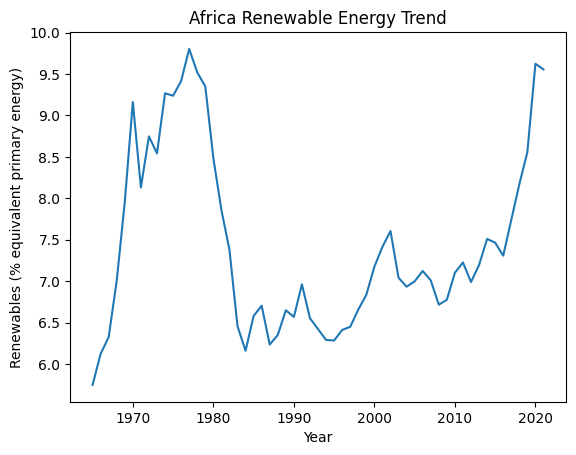

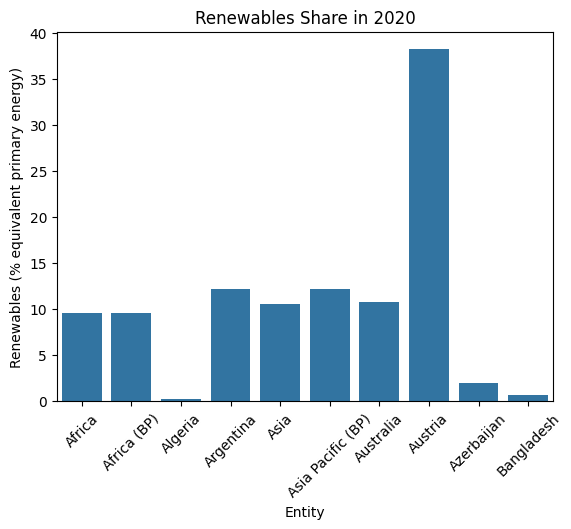

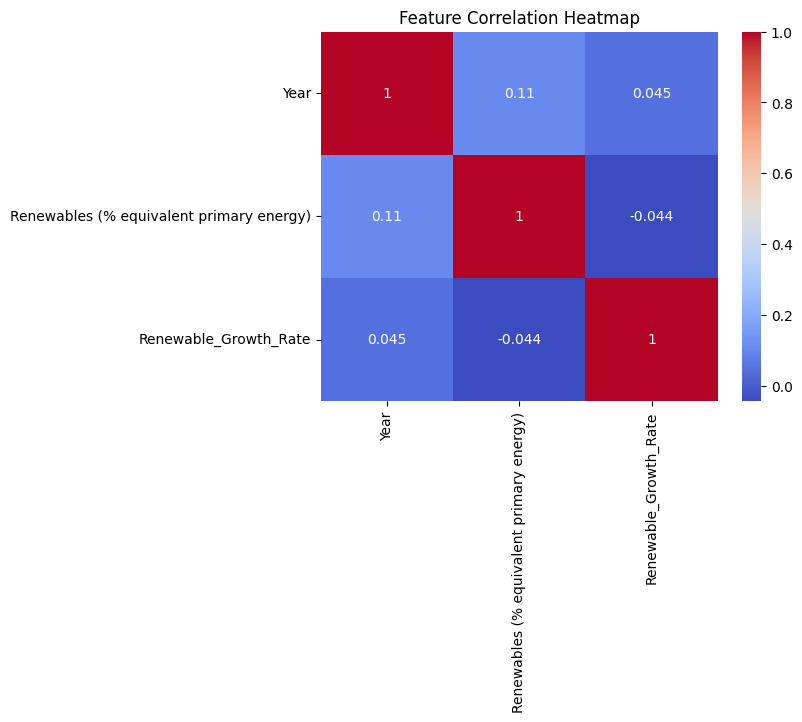

In [ ]:
# Trend over years for Africa
sns.lineplot(data=df[df['Entity']=='Africa'], x="Year", y="Renewables (% equivalent primary energy)")
plt.title("Africa Renewable Energy Trend")
plt.show()

# Compare countries (sample)
sns.barplot(data=df[df['Year']==2020].head(10), x="Entity", y="Renewables (% equivalent primary energy)")
plt.xticks(rotation=45)
plt.title("Renewables Share in 2020")
plt.show()

# Correlation heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()
